# Choosing a better training monitor than `tuning/loss`

**Question.** `ModelCheckpoint` and `EarlyStopping` in [`train/configs/config.yaml`](../train/configs/config.yaml) both watch `tuning/loss`. Is that the right signal, given the downstream metric we care about is held-out OOD `occurs_auc`?

**Finding.** `tuning/loss = tuning/occurs_loss + tuning/censor_loss`. Only the first term involves the outcome head we actually evaluate on downstream. In **all 7** arch-sweep runs, `tuning/occurs_loss` argmins **at or before** the same run's `tuning/loss` argmin, a median 338 training steps earlier. During those extra steps, `tuning/loss` keeps dropping only because `tuning/censor_loss` is still improving - meanwhile the outcome head has already started overfitting.

**Proposed change, one line each in [`config.yaml`](../train/configs/config.yaml):**

```yaml
model_checkpoint: { monitor: "tuning/occurs_loss" }
early_stopping:   { monitor: "tuning/occurs_loss" }
```

**Caveat.** We cannot directly prove this produces a better held-out OOD `occurs_auc`, because intermediate checkpoints were not preserved and we only have OOD numbers at `tuning/loss`'s argmin. This is a trajectory-shape argument, not a counterfactual measurement. §6 spells out the ~50-line experiment that would close the loop.

The rest of the notebook is the evidence. If you just want to see it, jump to §3.

## 1. Setup (skippable)

Loads everything once. After this cell:

- `runs` - one row per local training run (7 rows).
- `curves` - dict mapping `run_id` to per-step validation trajectories from W&B.
- `argopts` - one row per `(run, monitor)` pair: argopt step, value, and delta vs `tuning/loss`'s argmin in the same run.
- `ood` - held-out OOD AUROC snapshots on disk (2 runs only).

Requires `WANDB_ENTITY` and `WANDB_API_KEY` in a `.env` at the repo root.

In [ ]:
from __future__ import annotations

import os
import re
from datetime import datetime, timedelta, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns
import wandb
from dotenv import load_dotenv
from omegaconf import OmegaConf

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").is_file())
load_dotenv(REPO / ".env")
sns.set_theme(context="notebook", style="whitegrid")
OUTPUTS = REPO / "data" / "outputs"

WANDB_ENTITY = os.environ["WANDB_ENTITY"]
WANDB_PROJECT = os.environ.get("WANDB_PROJECT", "EveryQuery")

CANDIDATE_MONITORS = ["tuning/loss", "tuning/occurs_loss", "tuning/occurs_auc", "tuning/censor_auc"]
LOWER_IS_BETTER = {
    "tuning/loss": True, "tuning/occurs_loss": True, "tuning/censor_loss": True,
    "tuning/occurs_auc": False, "tuning/censor_auc": False,
}


# 1. Enumerate local runs and pull per-run config.
def _run_dirs(root: Path) -> list[Path]:
    return sorted(
        p for day in sorted(root.iterdir()) if day.is_dir()
        for p in sorted(day.iterdir())
        if p.is_dir() and (p / "resolved_config.yaml").is_file()
    )


def _run_id(p: Path) -> str:
    return f"{p.parent.name}/{p.name}"


def _most_recent_ood(run_dir: Path) -> Path | None:
    files = sorted((run_dir / "eval" / "best").glob("eval_aucs_held_out_*.parquet"))
    return files[-1] if files else None


run_dirs = _run_dirs(OUTPUTS)
runs = pl.DataFrame([
    {
        "run_id": _run_id(rd),
        "num_layers": OmegaConf.load(rd / "resolved_config.yaml").lightning_module.model.get("num_hidden_layers"),
        "max_seq_len": OmegaConf.load(rd / "resolved_config.yaml").datamodule.config.get("max_seq_len"),
        "has_ood_eval": _most_recent_ood(rd) is not None,
    }
    for rd in run_dirs
])


# 2. Match each local run to its W&B run. Stamp drifts by ~1s; uses greedy
#    1-to-1 matching so two runs started in the same SLURM array second do not
#    collide onto a single W&B id.
def _local_dt(rid: str) -> datetime:
    return datetime.strptime(rid, "%Y-%m-%d/%H-%M-%S").replace(tzinfo=timezone.utc)


_STAMP_RE = re.compile(r"(\d{8}_\d{6})")


def _wandb_dt(name: str) -> datetime | None:
    m = _STAMP_RE.search(name or "")
    return datetime.strptime(m.group(1), "%Y%m%d_%H%M%S").replace(tzinfo=timezone.utc) if m else None


api = wandb.Api(timeout=30)
local_ids = runs["run_id"].to_list()
local_dts = [_local_dt(r) for r in local_ids]
wb_all = list(api.runs(
    f"{WANDB_ENTITY}/{WANDB_PROJECT}",
    filters={"created_at": {
        "$gte": (min(local_dts) - timedelta(hours=1)).isoformat(),
        "$lte": (max(local_dts) + timedelta(hours=12)).isoformat(),
    }},
    per_page=500,
))
pairs = sorted(
    (abs(_wandb_dt(r.name) - rdt), rid, r)
    for rid, rdt in zip(local_ids, local_dts)
    for r in wb_all
    if _wandb_dt(r.name) is not None and abs(_wandb_dt(r.name) - rdt) <= timedelta(seconds=5)
)
wb_by_run: dict[str, "wandb.apis.public.Run"] = {}
_claimed: set[str] = set()
for _, rid, r in pairs:
    if rid not in wb_by_run and r.id not in _claimed:
        wb_by_run[rid] = r
        _claimed.add(r.id)
runs = runs.with_columns(
    pl.Series("wandb_id", [wb_by_run[r].id if r in wb_by_run else None for r in local_ids])
)


# 3. Pull per-step validation trajectories from W&B. We do not pass `keys=` to
#    scan_history because the server path drops rows missing any key, and
#    different metrics log at different cadences.
def _pull(run) -> pl.DataFrame:
    rows = list(run.scan_history(page_size=5_000))
    if not rows:
        return pl.DataFrame()
    df = pl.from_dicts(rows, infer_schema_length=None).rename({"_step": "step"})
    cols = ["step"] + [
        m for m in ["tuning/loss", "tuning/occurs_loss", "tuning/censor_loss",
                    "tuning/occurs_auc", "tuning/censor_auc"]
        if m in df.columns
    ]
    return df.select(cols)


curves = {rid: _pull(wb_by_run[rid]) for rid in local_ids if rid in wb_by_run}


# 4. Compute argopt step for each (run, monitor).
def _argopt(df: pl.DataFrame, m: str) -> tuple[int | None, float | None]:
    if m not in df.columns:
        return None, None
    sub = df.select("step", m).drop_nulls(m)
    if sub.height == 0:
        return None, None
    i = sub[m].arg_min() if LOWER_IS_BETTER[m] else sub[m].arg_max()
    return int(sub.row(i)[0]), float(sub.row(i)[1])


argopt_rows = []
for rid, df in curves.items():
    base_step, _ = _argopt(df, "tuning/loss")
    for m in CANDIDATE_MONITORS:
        step, val = _argopt(df, m)
        argopt_rows.append({
            "run_id": rid,
            "monitor": m,
            "argopt_step": step,
            "best_value": val,
            "delta_vs_tuning_loss": (step - base_step) if (step is not None and base_step is not None) else None,
        })
argopts = pl.DataFrame(argopt_rows)


# 5. Load held-out OOD snapshots (only 2 runs have these on disk).
ood_frames = []
for rd in run_dirs:
    fp = _most_recent_ood(rd)
    if fp is None:
        continue
    df = pl.read_parquet(fp)
    agg = (
        df.group_by("bucket")
          .agg(pl.col("occurs_auc").mean().alias("mean_occurs_auc"))
          .with_columns(pl.lit(_run_id(rd)).alias("run_id"))
    )
    ood_frames.append(agg)
if ood_frames:
    ood = (
        pl.concat(ood_frames)
          .pivot(index="run_id", on="bucket", values="mean_occurs_auc", aggregate_function="first")
    )
    ood = ood.select(["run_id"] + [c for c in ["id", "ood", "manual"] if c in ood.columns])
else:
    ood = pl.DataFrame()

print(f"runs:    {runs.height}")
print(f"curves:  {len(curves)} runs with W&B trajectories ({sum(df.height for df in curves.values())} total rows)")
print(f"argopts: {argopts.height} (run, monitor) pairs")
print(f"ood:     {ood.height} held-out snapshots on disk")

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


runs:    7
curves:  7 runs with W&B trajectories (18610 total rows)
argopts: 28 (run, monitor) pairs
ood:     2 held-out snapshots on disk


## 2. The sweep

Seven runs, all seed `140799`, all 10k query codes. They differ only in `num_hidden_layers` and `max_seq_len`. Two of them have held-out OOD evaluations on disk (`has_ood_eval=True`), the other five do not. This arch-only sweep is a confound for cross-run comparisons - see §6.

In [2]:
runs

run_id,num_layers,max_seq_len,has_ood_eval,wandb_id
str,i64,i64,bool,str
"""2026-04-02/23-43-54""",22,256,true,"""hvp5lmr5"""
"""2026-04-02/23-43-55""",16,256,false,"""swzefm03"""
"""2026-04-02/23-54-43""",null,1028,true,"""aajtsbbq"""
"""2026-04-02/23-56-55""",6,1028,false,"""lg2ngvy5"""
"""2026-04-02/23-58-42""",12,1028,false,"""w14lli7w"""
"""2026-04-03/12-58-10""",12,256,false,"""1q33a2od"""
"""2026-04-03/13-28-12""",6,256,false,"""65vjqj30"""


## 3. Finding: where does each candidate monitor place `best_model.ckpt`?

For every run we pull the validation trajectory of each candidate monitor from W&B, find the step where it hit its best value, and subtract the step where `tuning/loss` hit its minimum in the same run.

**Read the figure as:** each row is a run; each marker is one candidate monitor's argopt step, centered on that run's `tuning/loss` argmin. Markers to the left of 0 mean that monitor would save an earlier checkpoint than `tuning/loss` does.

**Pattern:** the red diamond (`tuning/occurs_loss`) sits at or to the left of 0 in every run - it never places the checkpoint later than `tuning/loss` does. The orange square (`tuning/occurs_auc`) and blue triangle (`tuning/censor_auc`) are noisier, with one run each landing far to the right. That is why the recommendation is `tuning/occurs_loss` specifically, not one of the AUC metrics.

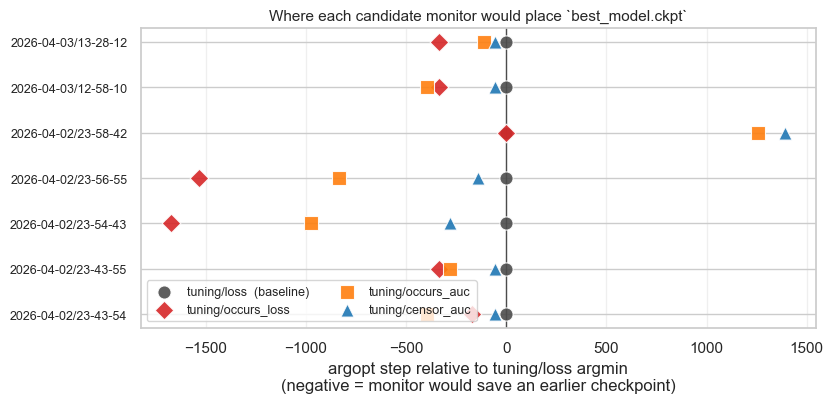

In [3]:
MARKERS = {
    "tuning/loss":        ("o", "#4c4c4c", "tuning/loss  (baseline)"),
    "tuning/occurs_loss": ("D", "#d62728", "tuning/occurs_loss"),
    "tuning/occurs_auc":  ("s", "#ff7f0e", "tuning/occurs_auc"),
    "tuning/censor_auc":  ("^", "#1f77b4", "tuning/censor_auc"),
}
y_labels = sorted(argopts["run_id"].unique().to_list())
y_to_idx = {y: i for i, y in enumerate(y_labels)}

fig, ax = plt.subplots(figsize=(8.5, 4.2))
for monitor, (mk, color, label) in MARKERS.items():
    sub = argopts.filter(pl.col("monitor") == monitor)
    ax.scatter(
        sub["delta_vs_tuning_loss"].to_numpy(),
        [y_to_idx[r] for r in sub["run_id"].to_list()],
        marker=mk, s=90, color=color, alpha=0.9, label=label,
        edgecolor="white", linewidth=0.8, zorder=3,
    )
ax.axvline(0, color="#4c4c4c", lw=1, zorder=2)
ax.set_yticks(range(len(y_labels)))
ax.set_yticklabels(y_labels, fontsize=9)
ax.set_xlabel("argopt step relative to tuning/loss argmin\n(negative = monitor would save an earlier checkpoint)")
ax.set_title("Where each candidate monitor would place `best_model.ckpt`", fontsize=11)
ax.legend(loc="lower left", frameon=True, fontsize=9, ncol=2)
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

### Summary across runs

In [4]:
(argopts
    .group_by("monitor")
    .agg(
        pl.col("argopt_step").median().alias("median_step"),
        pl.col("delta_vs_tuning_loss").median().alias("median_delta_vs_tuning_loss"),
        pl.col("delta_vs_tuning_loss").min().alias("min_delta"),
        pl.col("delta_vs_tuning_loss").max().alias("max_delta"),
        pl.col("best_value").mean().alias("mean_best_value"),
    )
    .sort("median_delta_vs_tuning_loss")
)

monitor,median_step,median_delta_vs_tuning_loss,min_delta,max_delta,mean_best_value
str,f64,f64,i64,i64,f64
"""tuning/occurs_auc""",1407.0,-396.0,-977,1255,0.920332
"""tuning/occurs_loss""",1350.0,-338.0,-1673,0,0.063423
"""tuning/censor_auc""",1462.0,-57.0,-282,1391,0.840408
"""tuning/loss""",1519.0,0.0,0,0,0.554009


## 4. Why: `tuning/loss` keeps falling after `occurs_loss` has already turned up

The run shown below has the largest gap in the sweep: `tuning/occurs_loss` argmins at step 2225, `tuning/loss` argmins 1673 steps later at step 3898. Three stacked panels, shared x-axis:

- **Top (gray):** `tuning/loss` - the current monitor. Keeps dropping right up to step 3898.
- **Middle (red):** `tuning/occurs_loss` - the proposed monitor. Bottoms at step 2225, **climbs noticeably** afterwards.
- **Bottom (blue):** `tuning/censor_loss` - the side head we do not evaluate on. Keeps dropping through step 3898.

`tuning/loss` equals the sum of the middle and bottom panels. The shaded red span is the ~1700 training steps where `tuning/occurs_loss` is already rising but `tuning/censor_loss` is dropping fast enough to pull the sum down. Any checkpoint saved inside this band has a *worse* outcome head than the one `tuning/occurs_loss` would have saved.

/var/folders/lf/0hr4t0g11t35265rmv8nv0vh0000gn/T/ipykernel_46832/4162466718.py:41: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


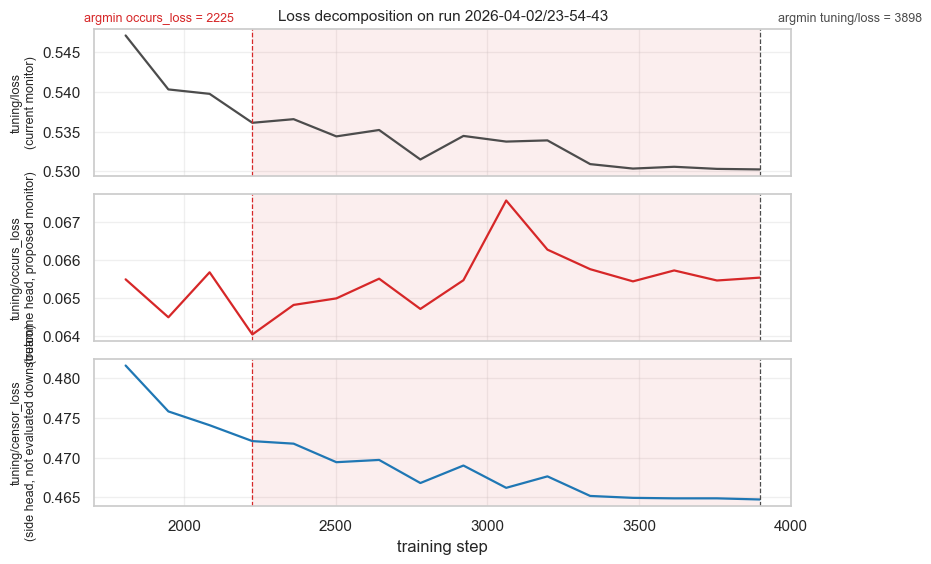

In [5]:
REPR = "2026-04-02/23-54-43"  # largest s_loss - s_occurs gap in the sweep (-1673)
df = curves[REPR]

s_loss, _ = _argopt(df, "tuning/loss")
s_occurs, _ = _argopt(df, "tuning/occurs_loss")
STEP_LO, STEP_HI = max(0, s_occurs - 500), df["step"].max()

fig, axes = plt.subplots(
    3, 1, figsize=(9, 6.2), sharex=True,
    gridspec_kw={"hspace": 0.12},
)
panels = [
    (axes[0], "tuning/loss",        "#4c4c4c", "tuning/loss\n(current monitor)"),
    (axes[1], "tuning/occurs_loss", "#d62728", "tuning/occurs_loss\n(outcome head, proposed monitor)"),
    (axes[2], "tuning/censor_loss", "#1f77b4", "tuning/censor_loss\n(side head, not evaluated downstream)"),
]
for ax, col, color, label in panels:
    sub = df.select("step", col).drop_nulls(col).filter(
        (pl.col("step") >= STEP_LO) & (pl.col("step") <= STEP_HI)
    )
    ax.plot(sub["step"].to_numpy(), sub[col].to_numpy(), color=color, lw=1.6)
    ax.axvspan(s_occurs, s_loss, color="#d62728", alpha=0.08, lw=0)
    ax.axvline(s_occurs, color="#d62728", ls="--", lw=0.9)
    ax.axvline(s_loss, color="#4c4c4c", ls="--", lw=0.9)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].set_title(f"Loss decomposition on run {REPR}", fontsize=11)
y_top = axes[0].get_ylim()[1]
axes[0].annotate(
    f"argmin occurs_loss = {s_occurs}",
    xy=(s_occurs, y_top), xytext=(s_occurs - 60, y_top * 1.001),
    color="#d62728", fontsize=9, ha="right", va="bottom",
)
axes[0].annotate(
    f"argmin tuning/loss = {s_loss}",
    xy=(s_loss, y_top), xytext=(s_loss + 60, y_top * 1.001),
    color="#4c4c4c", fontsize=9, ha="left", va="bottom",
)
axes[-1].set_xlabel("training step")
fig.tight_layout()
plt.show()

## 5. The OOD ground truth we have

Only two of the seven runs have `eval/best/eval_aucs_held_out_*.parquet` on disk, and those numbers are for the checkpoint that `tuning/loss` selected. There is no OOD number at the alternative checkpoint that `tuning/occurs_loss` would have saved, because intermediate checkpoints were not preserved. These two rows are anchors, not a comparison.

In [6]:
ood

run_id,id,ood,manual
str,f64,f64,f64
"""2026-04-02/23-43-54""",0.830463,0.843766,0.802213
"""2026-04-02/23-54-43""",0.830695,0.848544,null


## 6. Caveats and the experiment that would settle it

**What this notebook does not prove.**

- Only 2 of 7 runs have OOD ground truth, and those are at `tuning/loss`'s argmin only. No OOD number exists at the alternative checkpoint that `tuning/occurs_loss` would have selected.
- The 7 runs share seed `140799` and differ only in architecture. It is an arch sweep, not a statistical sample, and cross-run aggregates are confounded.
- The argument above is trajectory-shape: *if* overfitting the occurs head past its argmin degrades held-out OOD AUROC, *then* monitoring `tuning/occurs_loss` should help. The premise is plausible and consistent across all 7 runs, but not measured.

**The experiment that closes the loop.** Either is cheap:

- **(a) Preserve intermediate checkpoints on the next run.** [`config.yaml`](../train/configs/config.yaml) already requests `save_top_k: -1`; just stop deleting the `checkpoints/` directory after training. Then run [`evaluate/eval.py`](../evaluate/eval.py) in its `ckpt_names: [...]` loop over each saved step. Zero new code; config + don't-delete.
- **(b) Add a `LightningCallback`** that samples a held-out OOD code bucket every K validation ticks, computes `occurs_auc` on it, and logs as `tuning/ood_occurs_auc`. Makes the OOD trajectory visible live in W&B and removes the intermediate-ckpt dependency. Roughly 50 lines.

Either would let us answer the one question this notebook could not: *does the earlier checkpoint actually generalize better?*